# Lab 10 - Aprendizaje Semi-Supervisado
## Grupo 02: Co-Training
Idea central: uso de multiples vistas independientes del dataset 
Temas: 
- Supuesto de independencia condicional 
- Feature splitting 
- Algoritmos: Co-training con clasificadores distintos (ej. Naive Bayes + SVM) 

**Dataset:** Mushroom Classification (UCI / Kaggle)  
**Fuente:** https://www.kaggle.com/datasets/uciml/mushroom-classification  

In [43]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## Fase 2 — Selección y Análisis del Dataset

### 2a. Carga del dataset

In [44]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/mushroom-classification",
    "mushrooms.csv",
)

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 8124 filas × 23 columnas


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### 2b. Análisis y Exploración de Datos (EDA)

In [45]:

print('INFORMACIÓN GENERAL DEL DATASET')

print(f'Filas    : {df.shape[0]:,}')
print(f'Columnas : {df.shape[1]}')
print(f'Variable objetivo: class (p = venenoso, e = comestible)')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())

INFORMACIÓN GENERAL DEL DATASET
Filas    : 8,124
Columnas : 23
Variable objetivo: class (p = venenoso, e = comestible)

Tipos de datos:
str    23
Name: count, dtype: int64


In [46]:
# Descripción de columnas con sus valores únicos
descripcion = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique(),
    'Valores nulos': df.isnull().sum(),
    '% nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores posibles': df.apply(lambda col: sorted(col.unique().tolist()))
})

print('\nResumen de columnas:')
descripcion


Resumen de columnas:


,Tipo,Valores únicos,Valores nulos,% nulos,Valores posibles
class,str,2,0,0.0,"[e, p]"
cap-shape,str,6,0,0.0,"[b, c, f, k, s, x]"
cap-surface,str,4,0,0.0,"[f, g, s, y]"
cap-color,str,10,0,0.0,"[b, c, e, g, n, p, r, u, w, y]"
bruises,str,2,0,0.0,"[f, t]"
odor,str,9,0,0.0,"[a, c, f, l, m, n, p, s, y]"
gill-attachment,str,2,0,0.0,"[a, f]"
gill-spacing,str,2,0,0.0,"[c, w]"
gill-size,str,2,0,0.0,"[b, n]"
gill-color,str,12,0,0.0,"[b, e, g, h, k, n, o, p, r, u, w, y]"


In [47]:
# Estadísticas descriptivas para variables categóricas
print('Estadísticas descriptivas (variables categóricas):')
df.describe(include='object')

Estadísticas descriptivas (variables categóricas):


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [48]:
# Distribución de clases
class_counts = df['class'].value_counts()
class_labels = {'p': 'Venenoso (p)', 'e': 'Comestible (e)'}
class_counts.index = class_counts.index.map(class_labels)

print('Distribución de clases:')
print(class_counts.to_frame('Cantidad').assign(Porcentaje=lambda x: (x['Cantidad'] / len(df) * 100).round(2)))
print()
print(f'Balance de clases: {class_counts.min() / class_counts.max():.3f}  (1.0 = perfecto)')

Distribución de clases:
                Cantidad  Porcentaje
class                               
Comestible (e)      4208        51.8
Venenoso (p)        3916        48.2

Balance de clases: 0.931  (1.0 = perfecto)


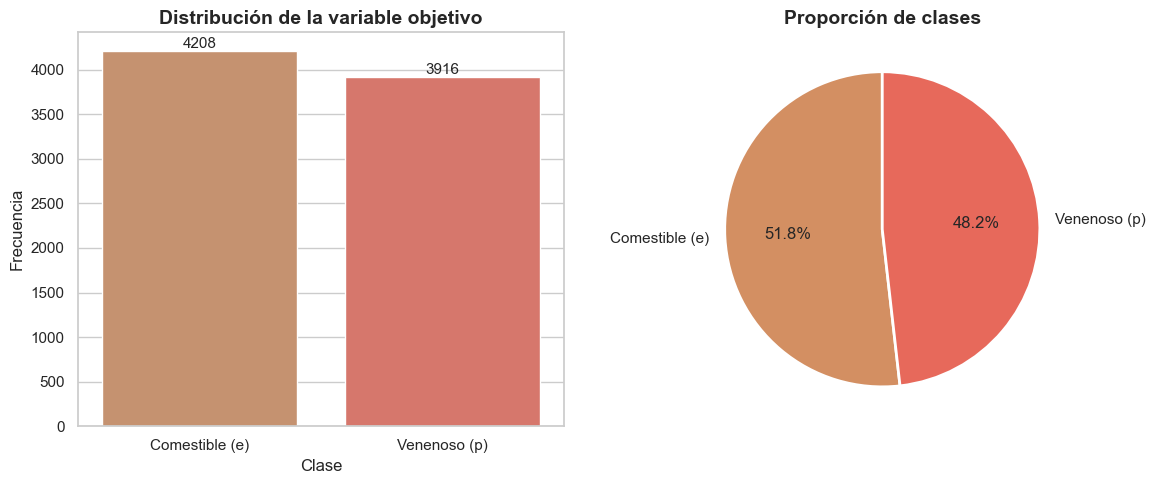

Figura 1. Distribución de la variable objetivo (class).


In [49]:
# Gráfico de distribución de clases — Seaborn + Plotly
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
sns.countplot(data=df, x='class', palette=["#d38f62", "#e7695b"],
              order=['e', 'p'], ax=axes[0])
axes[0].set_title('Distribución de la variable objetivo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['Comestible (e)', 'Venenoso (p)'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=["#d38f62", "#e7695b"],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=14, fontweight='bold')

plt.tight_layout()
#plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1. Distribución de la variable objetivo (class).')

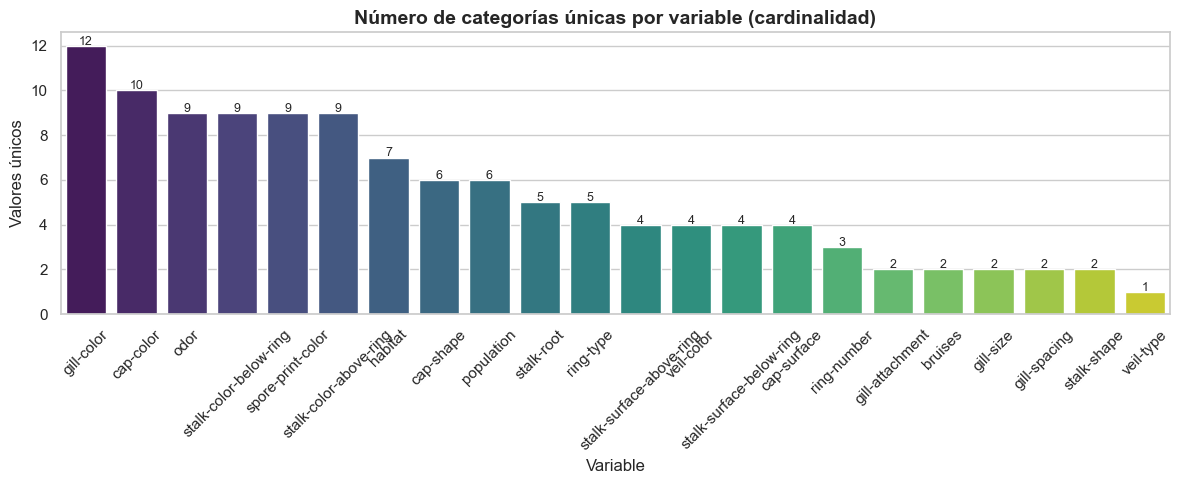

Figura 2. Cardinalidad (número de valores únicos) por variable.


In [50]:
# Frecuencia de cada categoría por variable — heatmap de cardinalidad
cardinalidad = df.nunique().sort_values(ascending=False).drop('class')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=cardinalidad.index, y=cardinalidad.values,
            palette='viridis', ax=ax)
ax.set_title('Número de categorías únicas por variable (cardinalidad)', fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Valores únicos')
ax.tick_params(axis='x', rotation=45)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
#plt.savefig('cardinalidad_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2. Cardinalidad (número de valores únicos) por variable.')

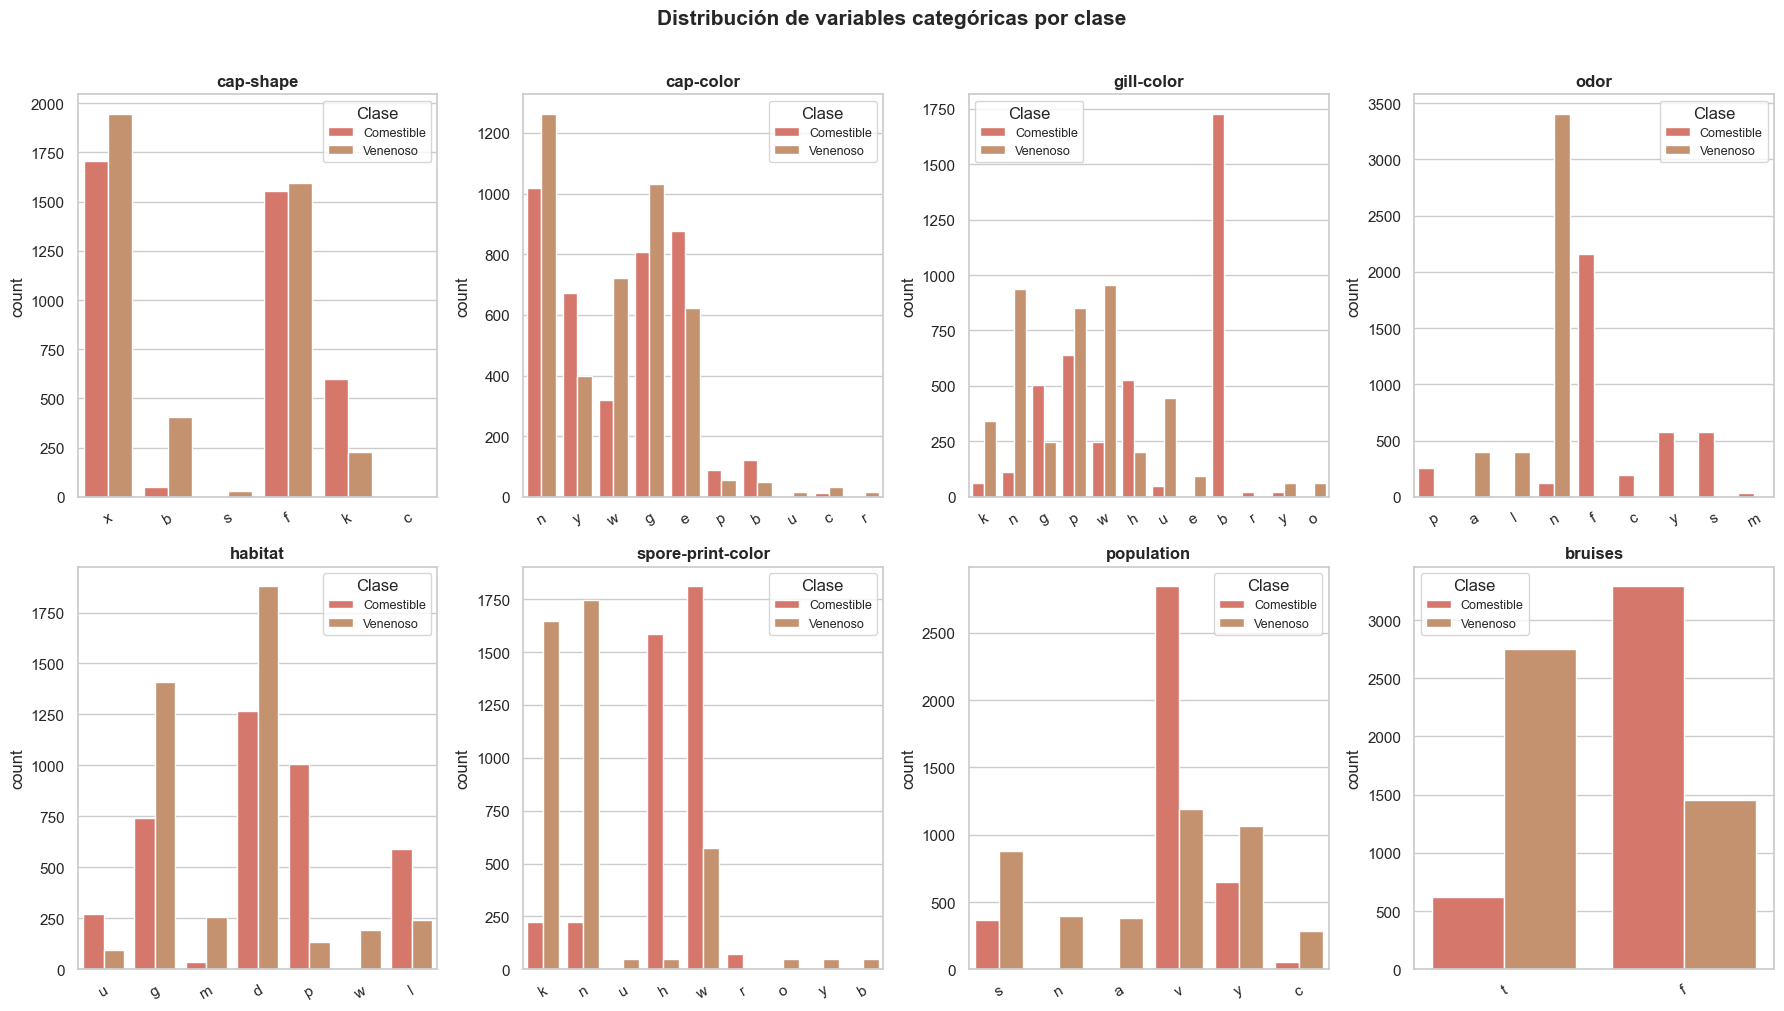

Figura 3. Distribución de 8 variables categóricas clave segmentadas por clase objetivo.


In [51]:
# Distribución de las primeras 8 variables más importantes vs clase objetivo — Seaborn
features_plot = ['cap-shape', 'cap-color', 'gill-color', 'odor',
                 'habitat', 'spore-print-color', 'population', 'bruises']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_plot):
    sns.countplot(data=df, x=col, hue='class',
                  palette={'e': '#d38f62', 'p': '#e7695b'}, 
                  ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Clase', labels=['Comestible', 'Venenoso'], fontsize=9)

plt.suptitle('Distribución de variables categóricas por clase', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('distribucion_variables_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3. Distribución de 8 variables categóricas clave segmentadas por clase objetivo.')

#### Análisis de valores nulos y calidad del dato

In [52]:
# El dataset Mushroom tiene una columna especial: 'stalk-root' con '?' como missing
# Detectamos y reportamos esto

missing_explicit = (df == '?').sum()
missing_explicit = missing_explicit[missing_explicit > 0]

print('Valores nulos convencionales (NaN):', df.isnull().sum().sum())
print()
if len(missing_explicit) > 0:
    print('Columnas con "?" (missing implícito):')
    for col, count in missing_explicit.items():
        pct = count / len(df) * 100
        print(f'  {col}: {count} registros ({pct:.1f}%)')
else:
    print('No se encontraron valores "?" en el dataset.')

Valores nulos convencionales (NaN): 0

Columnas con "?" (missing implícito):
  stalk-root: 2480 registros (30.5%)


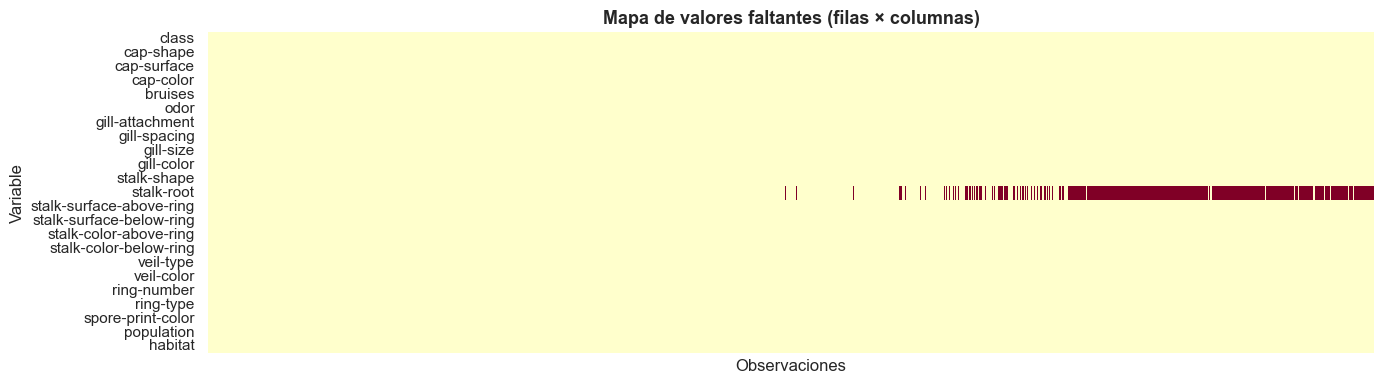

Figura 4. Mapa de valores faltantes. Amarillo/rojo indica ausencia de dato.


In [53]:
# Visualización de missing values con heatmap (Seaborn)
# Reemplazamos '?' por NaN para visualizar correctamente
df_viz = df.replace('?', np.nan)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_viz.isnull().T,
            cmap='YlOrRd', cbar=False,
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Mapa de valores faltantes (filas × columnas)', fontsize=13, fontweight='bold')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Variable')
plt.tight_layout()
#plt.savefig('missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4. Mapa de valores faltantes. Amarillo/rojo indica ausencia de dato.')

### Análisis de la variable odor — predictora clave

In [54]:
# 'odor' es conocida por ser altamente discriminativa en este dataset
odor_map = {
    'a': 'almendra', 'l': 'anís', 'c': 'creosota',
    'y': 'pescado', 'f': 'fétido', 'm': 'a tierra',
    'n': 'ninguno', 'p': 'picante', 's': 'a especias'
}

df_odor = df.copy()
df_odor['odor_label'] = df_odor['odor'].map(odor_map)

odor_class = df_odor.groupby(['odor_label', 'class']).size().unstack(fill_value=0)
odor_class.columns = ['Comestible', 'Venenoso']
odor_class = odor_class.sort_values('Venenoso', ascending=False)

fig = px.bar(
    odor_class.reset_index(), x='odor_label',
    y=['Comestible', 'Venenoso'],
    barmode='group',
    color_discrete_map={'Comestible': '#d38f62', 'Venenoso': '#e7695b'},
    title='Distribución de clases según tipo de olor (odor)',
    labels={'odor_label': 'Olor', 'value': 'Frecuencia', 'variable': 'Clase'}
)
fig.update_layout(plot_bgcolor='white', title_font_size=15)
fig.show()
print('Figura 5. La variable odor es altamente discriminativa: olores como fétido, a especias y creosota son exclusivos de hongos venenosos.')

Figura 5. La variable odor es altamente discriminativa: olores como fétido, a especias y creosota son exclusivos de hongos venenosos.


### Correlación entre variables (Cramér's V)

In [55]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula el coeficiente V de Cramér entre dos variables categóricas."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Calculamos Cramér's V para todas las columnas vs la variable clase
cols = [c for c in df.columns if c != 'class']
cramers_vs_class = {}
for col in cols:
    try:
        cramers_vs_class[col] = cramers_v(df[col], df['class'])
    except Exception:
        cramers_vs_class[col] = np.nan

cramers_series = pd.Series(cramers_vs_class).sort_values(ascending=False)

print('Asociación de cada variable con la clase objetivo (Cramér\'s V):')
print(cramers_series.round(3).to_frame('Cramér\'s V'))

Asociación de cada variable con la clase objetivo (Cramér's V):
                          Cramér's V
odor                           0.971
spore-print-color              0.753
gill-color                     0.681
ring-type                      0.603
stalk-surface-above-ring       0.588
stalk-surface-below-ring       0.575
gill-size                      0.540
stalk-color-above-ring         0.525
stalk-color-below-ring         0.515
bruises                        0.501
population                     0.487
habitat                        0.440
stalk-root                     0.407
gill-spacing                   0.348
cap-shape                      0.246
cap-color                      0.218
ring-number                    0.215
cap-surface                    0.197
veil-color                     0.153
gill-attachment                0.128
stalk-shape                    0.102
veil-type                        NaN


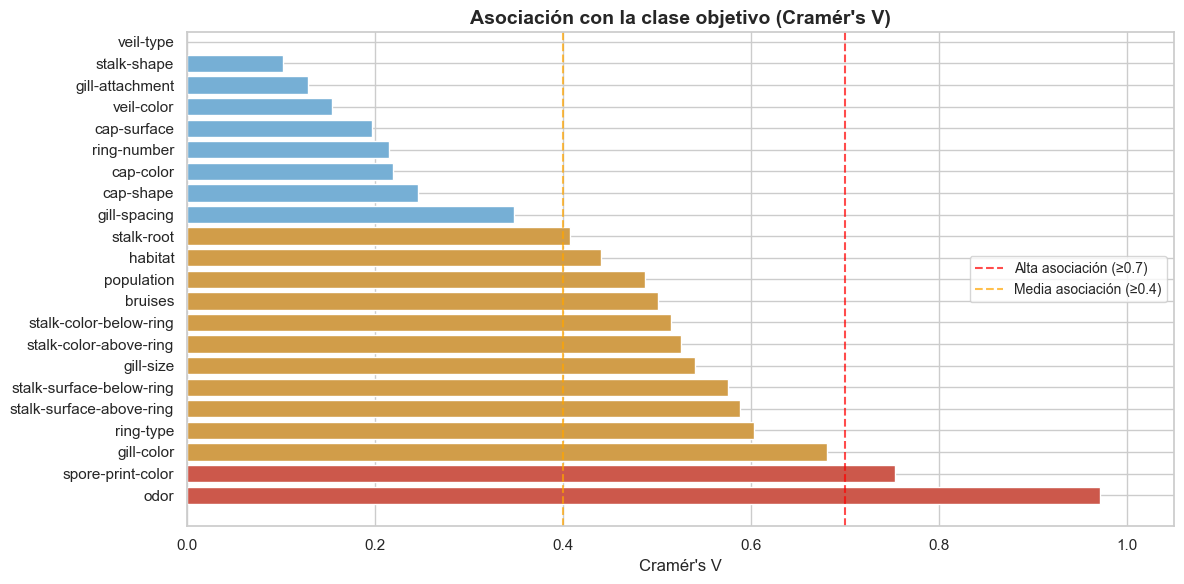

Figura 6. Asociación entre variables predictoras y la clase objetivo medida con Cramér's V. Rojo = alta asociación.


In [56]:
# Visualización — Barplot de Cramér's V vs clase
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#cc584b" if v >= 0.7 else "#d19d49" if v >= 0.4 else "#76afd5"
          for v in cramers_series.values]

bars = ax.barh(cramers_series.index, cramers_series.values, color=colors)
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.7, label='Alta asociación (≥0.7)')
ax.axvline(x=0.4, color='orange', linestyle='--', alpha=0.7, label='Media asociación (≥0.4)')
ax.set_title("Asociación con la clase objetivo (Cramér's V)", fontsize=14, fontweight='bold')
ax.set_xlabel("Cramér's V")
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
#plt.savefig('cramers_v_vs_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 6. Asociación entre variables predictoras y la clase objetivo medida con Cramér's V. Rojo = alta asociación.")

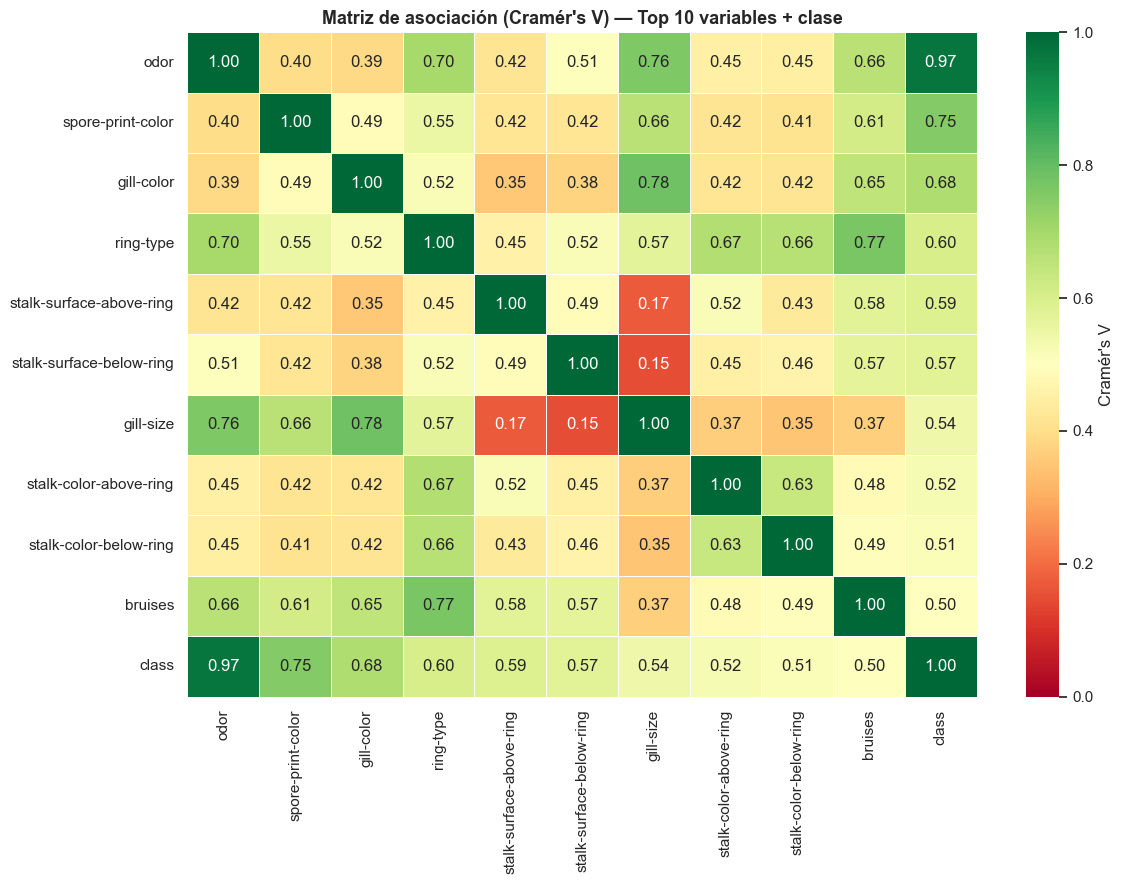

Figura 7. Heatmap de Cramér's V entre las 10 variables más predictivas y la clase objetivo.


In [57]:
# Heatmap de Cramér's V entre todas las variables (matriz completa)
# Computacionalmente costoso — usamos un subconjunto de las 10 más asociadas
top_features = cramers_series.head(10).index.tolist() + ['class']
df_top = df[top_features]

all_cols = df_top.columns.tolist()
matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for c1 in all_cols:
    for c2 in all_cols:
        if c1 == c2:
            matrix.loc[c1, c2] = 1.0
        elif pd.isna(matrix.loc[c1, c2]):
            v = cramers_v(df_top[c1], df_top[c2])
            matrix.loc[c1, c2] = v
            matrix.loc[c2, c1] = v

matrix = matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5,
            ax=ax, cbar_kws={'label': "Cramér's V"})
ax.set_title("Matriz de asociación (Cramér's V) — Top 10 variables + clase",
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('heatmap_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 7. Heatmap de Cramér's V entre las 10 variables más predictivas y la clase objetivo.")

### Análisis interactivo con Plotly — Distribución general de variables

In [58]:
# Sunburst interactivo: habitat → class
df_sun = df.copy()

habitat_map = {
    'g': 'Pasto', 'l': 'Hojas', 'm': 'Pradera',
    'p': 'Caminos', 'u': 'Urbano', 'w': 'Desperdicio', 'd': 'Bosque'
}
class_map = {'p': 'Venenoso', 'e': 'Comestible'}
df_sun['habitat_label'] = df_sun['habitat'].map(habitat_map)
df_sun['class_label'] = df_sun['class'].map(class_map)

fig = px.sunburst(
    df_sun,
    path=['habitat_label', 'class_label'],
    color='class_label',
    color_discrete_map={'Comestible': '#d38f62', 'Venenoso': '#e7695b'},
    title='Distribución de hongos por hábitat y clase'
)
fig.update_layout(title_font_size=15)
fig.show()
print('Figura 8. Sunburst interactivo: composición de clases dentro de cada hábitat.')

Figura 8. Sunburst interactivo: composición de clases dentro de cada hábitat.


### Análisis de tasa de toxicidad por categoría — Variables más discriminativas

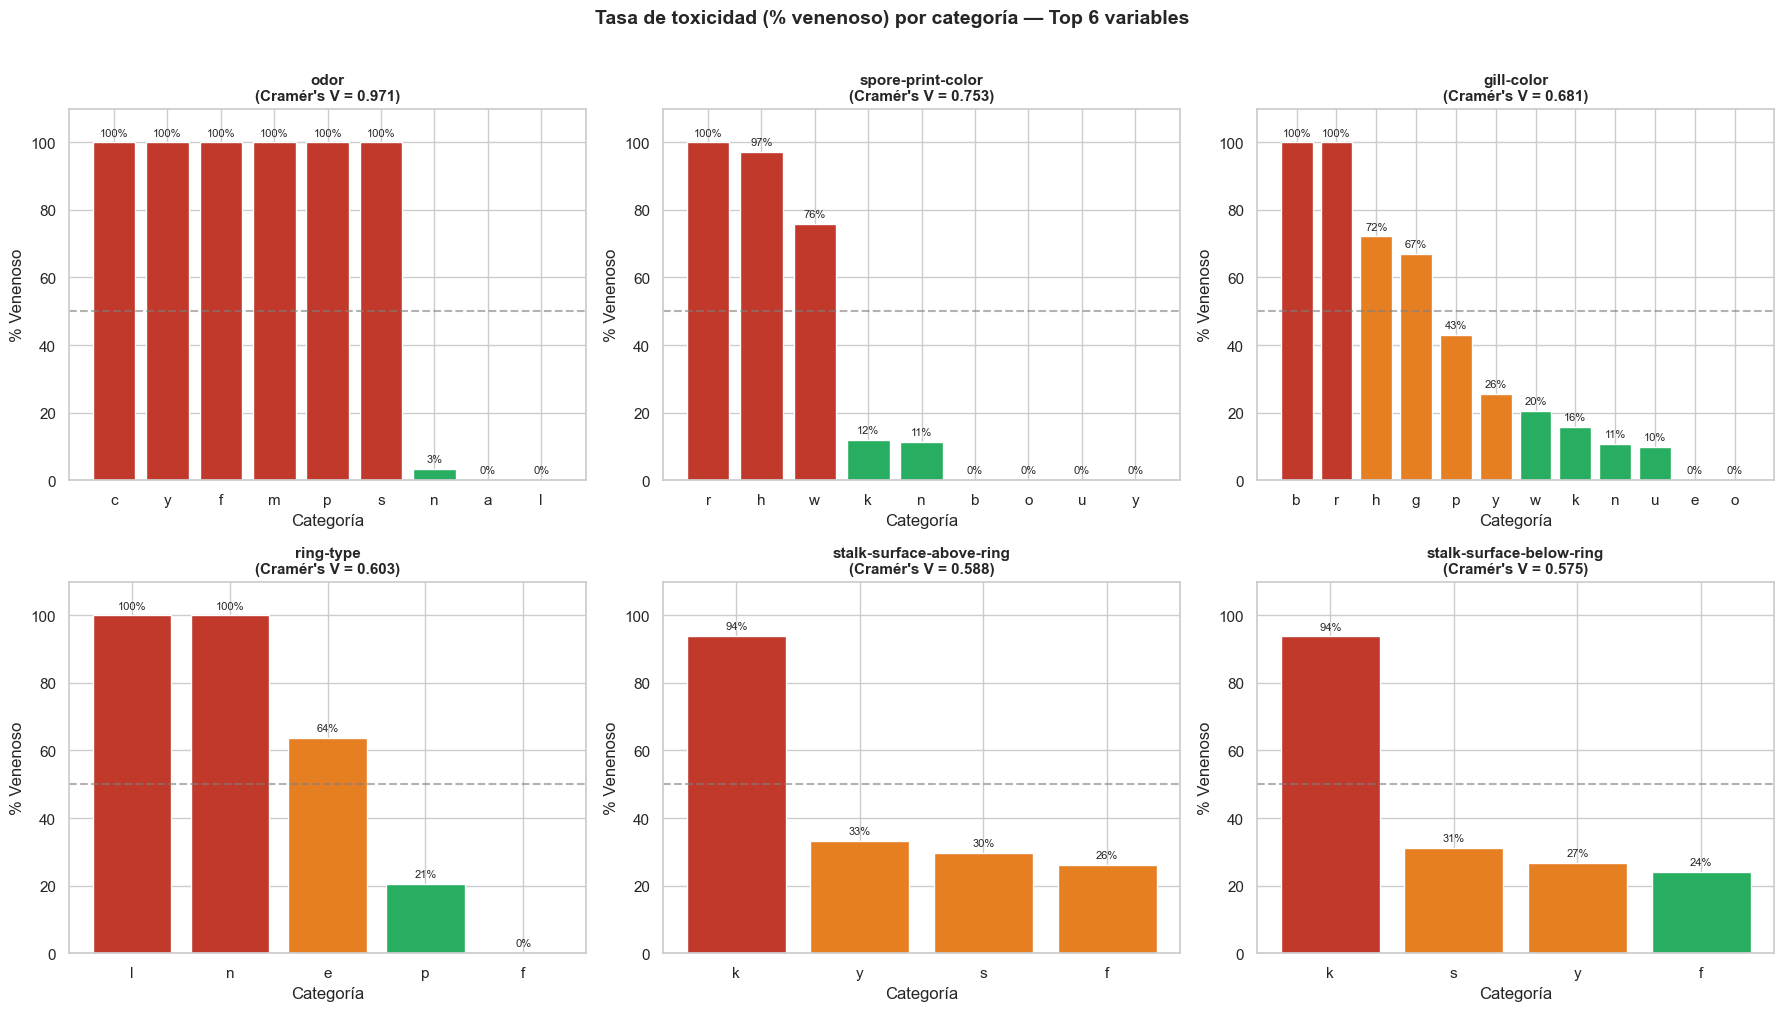

Figura C. Rojo = categoría mayoritariamente venenosa (≥75%), naranja = mixta, verde = mayoritariamente comestible.


In [59]:
# Tasa de toxicidad (% venenoso) por categoría en las top 6 variables
top6 = cramers_series.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    tox_rate = (
        df.groupby(col)['class']
        .apply(lambda x: (x == 'p').sum() / len(x) * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    tox_rate.columns = ['categoria', 'pct_venenoso']

    colors = ['#c0392b' if v >= 75 else '#e67e22' if v >= 25 else '#27ae60'
              for v in tox_rate['pct_venenoso']]
    axes[i].bar(tox_rate['categoria'], tox_rate['pct_venenoso'], color=colors)
    axes[i].axhline(50, color='gray', linestyle='--', alpha=0.6)
    axes[i].set_title(f'{col}\n(Cramér\'s V = {cramers_series[col]:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% Venenoso')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylim(0, 110)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     f'{bar.get_height():.0f}%', ha='center', fontsize=8)

plt.suptitle('Tasa de toxicidad (% venenoso) por categoría — Top 6 variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('tasa_toxicidad_top6.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura C. Rojo = categoría mayoritariamente venenosa (≥75%), naranja = mixta, verde = mayoritariamente comestible.')

### 2c–d. Preprocesamiento de datos y limpieza

Los pasos aplicados son:
1. **Imputación de valores faltantes** — `stalk-root` contiene `?` (30.5%). Se imputa con la moda.
2. **Eliminación de variables constantes** — `veil-type` tiene un único valor en todo el dataset; no aporta información discriminativa.
3. **Codificación Label Encoding** — se asigna un entero a cada categoría. Apropiada para Naive Bayes y para mantener los nombres de columna originales necesarios en el feature splitting de Co-Training.

In [60]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# 1. Reemplazar '?' por NaN y rellenar con la moda de la columna
df_clean = df_clean.replace('?', np.nan)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f'Columna "{col}": {df[col].eq("?").sum()} valores faltantes → imputados con moda ("{moda}")')

# 2. Eliminar variable constante
df_clean.drop(columns=['veil-type'], inplace=True)
print(f"\nEliminada 'veil-type': {df.shape[1]} → {df_clean.shape[1]} columnas")

# 3. Label Encoding de todas las columnas categóricas
le = LabelEncoder()
df_encoded = df_clean.apply(le.fit_transform)

print(f'\nDataset preprocesado: {df_encoded.shape}')
df_encoded.head()

Columna "stalk-root": 2480 valores faltantes → imputados con moda ("b")

Eliminada 'veil-type': 23 → 22 columnas

Dataset preprocesado: (8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


In [61]:
# Separar X e y
X = df_encoded.drop(columns=['class'])

# En LabelEncoder alfabético: e=0 (comestible), p=1 (venenoso)
# Verificamos que 1 = venenoso antes de continuar
y_bin = df_encoded['class']  # 0 = comestible, 1 = venenoso
assert df_clean['class'].unique().tolist(), 'Verificar encoding'

print(f'X shape   : {X.shape}')
print(f'y shape   : {y_bin.shape}')
print(f'Distribución y: {dict(y_bin.value_counts())}  (0=comestible, 1=venenoso)')

# Guardamos para uso del equipo
X.to_csv('X_mushroom.csv', index=False)
y_bin.to_csv('y_mushroom.csv', index=False)
print('\nX_mushroom.csv e y_mushroom.csv guardados correctamente.')

X shape   : (8124, 21)
y shape   : (8124,)
Distribución y: {0: np.int64(4208), 1: np.int64(3916)}  (0=comestible, 1=venenoso)

X_mushroom.csv e y_mushroom.csv guardados correctamente.


In [62]:
# Resumen final del preprocesamiento
print("RESUMEN FINAL DE PREPROCESAMIENTO")
print()
print(f"Dataset original       : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Valores faltantes (?)  : 2,480 en 'stalk-root' → imputados con moda")
print(f"Variables eliminadas   : 'veil-type' (constante, un solo valor)")
print(f"Dataset limpio         : {df_encoded.shape[0]:,} filas × {df_encoded.shape[1]} columnas")
print()
print(f"Codificación           : Label Encoding — {X.shape[1]} columnas")
print()
print("Archivos guardados     : X_mushroom.csv, y_mushroom.csv")

RESUMEN FINAL DE PREPROCESAMIENTO

Dataset original       : 8,124 filas × 23 columnas
Valores faltantes (?)  : 2,480 en 'stalk-root' → imputados con moda
Variables eliminadas   : 'veil-type' (constante, un solo valor)
Dataset limpio         : 8,124 filas × 22 columnas

Codificación           : Label Encoding — 21 columnas

Archivos guardados     : X_mushroom.csv, y_mushroom.csv


## Fase 3 — Diseño Experimental

### 3a. Separación de datos y definición de vistas

Se dividen los datos en train/test (80/20 estratificado) y se construyen dos vistas independientes sobre el conjunto de entrenamiento, respetando el supuesto de independencia condicional del Co-Training:

- **Vista 1** (Naive Bayes): características del sombrero, láminas, olor y magulladuras — `cap-*`, `gill-*`, `bruises`, `odor`
- **Vista 2** (SVM): características del tallo, anillo, esporas, población y hábitat — `stalk-*`, `ring-*`, `spore-print-color`, `population`, `habitat`

In [63]:
# Definición explícita de las dos vistas para Co-Training
# Vista 1 (Naive Bayes): características morfológicas del sombrero, láminas, olor y magulladuras
vista1_cols = [
    'cap-shape', 'cap-surface', 'cap-color', 'bruises',
    'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color'
]

# Vista 2 (SVM): características del tallo, anillo, esporas, población y hábitat
vista2_cols = [
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring',
    'stalk-color-above-ring', 'stalk-color-below-ring',
    'veil-color', 'ring-number', 'ring-type',
    'spore-print-color', 'population', 'habitat'
]

print(f'Vista 1 ({len(vista1_cols)} features): {vista1_cols}')
print(f'Vista 2 ({len(vista2_cols)} features): {vista2_cols}')

Vista 1 (9 features): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']
Vista 2 (12 features): ['stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [64]:
# 3.1 — Preparación de las vistas para Co-Training
# Usamos X (LabelEncoder) que mantiene los nombres de columna originales de X_raw
# para construir las dos vistas independientes requeridas por el algoritmo Co-Training.

# Aseguramos que X es un DataFrame con columnas nombradas (igual que X_raw)
import pandas as pd
from sklearn.model_selection import train_test_split

# Convertir X a DataFrame si no lo es (preserva nombres de columna)
if not isinstance(X, pd.DataFrame):
    X_df = pd.DataFrame(X, columns=X_raw.columns)
else:
    X_df = X.copy()

# Filtrar columnas de cada vista usando las listas definidas en P2
X_v1 = X_df[vista1_cols].reset_index(drop=True)  # Vista 1: cap-*, gill-*, bruises, odor
X_v2 = X_df[vista2_cols].reset_index(drop=True)  # Vista 2: stalk-*, spore-*, population, habitat, ring-*, veil-*

print(f'Vista 1 - columnas ({len(vista1_cols)}): {vista1_cols}')
print(f'Vista 2 - columnas ({len(vista2_cols)}): {vista2_cols}')
print()

# División train/test estratificada (80/20, random_state=42) — idéntica para ambas vistas
(
    X_v1_train, X_v1_test,
    X_v2_train, X_v2_test,
    y_train_ss, y_test_ss
) = train_test_split(
    X_v1, X_v2, y_bin,
    test_size=0.2, random_state=42, stratify=y_bin
)

# Resetear índices para facilitar el acceso posicional
X_v1_train = X_v1_train.reset_index(drop=True)
X_v1_test  = X_v1_test.reset_index(drop=True)
X_v2_train = X_v2_train.reset_index(drop=True)
X_v2_test  = X_v2_test.reset_index(drop=True)
import numpy as np
y_train_ss = np.array(y_train_ss)
y_test_ss  = np.array(y_test_ss)

print('Dimensiones de cada split:')
print(f'  X_v1_train : {X_v1_train.shape}  |  X_v1_test : {X_v1_test.shape}')
print(f'  X_v2_train : {X_v2_train.shape}  |  X_v2_test : {X_v2_test.shape}')
print(f'  y_train_ss : {y_train_ss.shape}   |  y_test_ss : {y_test_ss.shape}')
print()
print(f'  Balance venenoso — train: {y_train_ss.mean()*100:.1f}%  |  test: {y_test_ss.mean()*100:.1f}%')
print('\nVistas preparadas correctamente.')


Vista 1 - columnas (9): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']
Vista 2 - columnas (12): ['stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Dimensiones de cada split:
  X_v1_train : (6499, 9)  |  X_v1_test : (1625, 9)
  X_v2_train : (6499, 12)  |  X_v2_test : (1625, 12)
  y_train_ss : (6499,)   |  y_test_ss : (1625,)

  Balance venenoso — train: 48.2%  |  test: 48.2%

Vistas preparadas correctamente.


### 3b. Evaluación del porcentaje de datos etiquetados

Se simulan tres escenarios semi-supervisados variando la fracción de datos etiquetados: **5%, 10% y 20%**. El resto del train set se trata como no etiquetado. El muestreo es estratificado para preservar el balance de clases.

In [65]:
# 3.2 Función de simulación semi-supervisada
# Esta función divide el conjunto de entrenamiento en una porción «etiquetada»
# (que el modelo verá) y una porción «no etiquetada» (que simula datos sin etiquetar).
# El muestreo es ESTRATIFICADO para preservar el balance de clases original.

def simular_semisupervisado(X_v1_tr, X_v2_tr, y_tr, pct_etiquetado, random_state=42):
    import numpy as np
    from sklearn.model_selection import train_test_split

    y_arr = np.array(y_tr)
    n_total = len(y_arr)
    n_labeled = max(2, int(n_total * pct_etiquetado))  # mínimo 2 para stratify

    # Muestreo estratificado: separamos el % etiquetado del resto
    labeled_idx, unlabeled_idx = train_test_split(
        np.arange(n_total),
        train_size=n_labeled,
        random_state=random_state,
        stratify=y_arr
    )

    return {
        'labeled_idx'   : labeled_idx,
        'unlabeled_idx' : unlabeled_idx,
        'X_v1_labeled'  : X_v1_tr.iloc[labeled_idx].reset_index(drop=True),
        'X_v2_labeled'  : X_v2_tr.iloc[labeled_idx].reset_index(drop=True),
        'X_v1_unlabeled': X_v1_tr.iloc[unlabeled_idx].reset_index(drop=True),
        'X_v2_unlabeled': X_v2_tr.iloc[unlabeled_idx].reset_index(drop=True),
        'y_labeled'     : y_arr[labeled_idx],
        'y_unlabeled'   : y_arr[unlabeled_idx],   # ocultas — solo para evaluación
        'pct'           : pct_etiquetado,
        'n_labeled'     : n_labeled,
        'n_unlabeled'   : n_total - n_labeled,
    }

print('Función simular_semisupervisado() definida correctamente.')


Función simular_semisupervisado() definida correctamente.


### Generación de los 3 escenarios


In [66]:
# 3.3 Generación de los 3 escenarios requeridos por el laboratorio
# Porcentajes de etiquetado: 5%, 10% y 20% del train set.

escenarios = {
    '5%' : simular_semisupervisado(X_v1_train, X_v2_train, y_train_ss,
                                   pct_etiquetado=0.05, random_state=42),
    '10%': simular_semisupervisado(X_v1_train, X_v2_train, y_train_ss,
                                   pct_etiquetado=0.10, random_state=42),
    '20%': simular_semisupervisado(X_v1_train, X_v2_train, y_train_ss,
                                   pct_etiquetado=0.20, random_state=42),
}

print('ESCENARIOS SEMI-SUPERVISADOS GENERADOS')
for nombre, esc in escenarios.items():
    y_lab = esc['y_labeled']
    n_com = (y_lab == 0).sum()   # comestibles (clase 0)
    n_ven = (y_lab == 1).sum()   # venenosos   (clase 1)
    pct_ven = n_ven / len(y_lab) * 100

    print(f"  Escenario {nombre}")
    print(f"    Porcentaje etiquetado : {esc['pct']*100:.0f}%")
    print(f"    Muestras etiquetadas  : {esc['n_labeled']:,}")
    print(f"    Muestras no etiquetadas: {esc['n_unlabeled']:,}")
    print(f"    Balance (etiquetadas) : {n_com} comestible / {n_ven} venenoso ({pct_ven:.1f}% venenoso)")
    print()

print('Escenarios almacenados en el diccionario `escenarios`.')


ESCENARIOS SEMI-SUPERVISADOS GENERADOS
  Escenario 5%
    Porcentaje etiquetado : 5%
    Muestras etiquetadas  : 324
    Muestras no etiquetadas: 6,175
    Balance (etiquetadas) : 168 comestible / 156 venenoso (48.1% venenoso)

  Escenario 10%
    Porcentaje etiquetado : 10%
    Muestras etiquetadas  : 649
    Muestras no etiquetadas: 5,850
    Balance (etiquetadas) : 336 comestible / 313 venenoso (48.2% venenoso)

  Escenario 20%
    Porcentaje etiquetado : 20%
    Muestras etiquetadas  : 1,299
    Muestras no etiquetadas: 5,200
    Balance (etiquetadas) : 673 comestible / 626 venenoso (48.2% venenoso)

Escenarios almacenados en el diccionario `escenarios`.


### Visualización de los escenarios


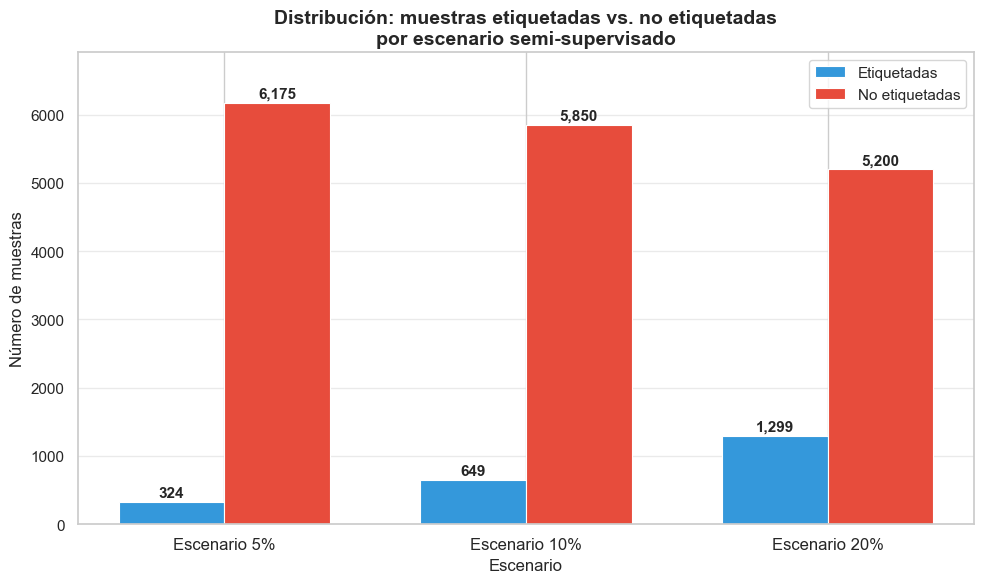

Figura P3-1. A mayor porcentaje de etiquetado, más muestras supervisadas disponibles,
             aunque la proporción no etiquetada sigue siendo dominante en todos los escenarios.


In [67]:
# 3.4  Visualización de los escenarios semi-supervisados
# Gráfico 1: Distribución etiquetado vs. no etiquetado por escenario

import matplotlib.pyplot as plt
import numpy as np

nombres_esc = list(escenarios.keys())
n_etiquetados   = [escenarios[k]['n_labeled']   for k in nombres_esc]
n_noetiquetados = [escenarios[k]['n_unlabeled']  for k in nombres_esc]

x = np.arange(len(nombres_esc))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_etiq   = ax.bar(x - ancho/2, n_etiquetados,   ancho,
                       label='Etiquetadas',     color='#3498db', edgecolor='white', linewidth=0.8)
barras_noetiq = ax.bar(x + ancho/2, n_noetiquetados, ancho,
                       label='No etiquetadas', color='#e74c3c', edgecolor='white', linewidth=0.8)

# Etiquetas de valor sobre cada barra
for bar in barras_etiq:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in barras_noetiq:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Escenario {k}' for k in nombres_esc], fontsize=12)
ax.set_ylabel('Número de muestras', fontsize=12)
ax.set_xlabel('Escenario', fontsize=12)
ax.set_title('Distribución: muestras etiquetadas vs. no etiquetadas\npor escenario semi-supervisado',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(n_noetiquetados) * 1.12)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print('Figura P3-1. A mayor porcentaje de etiquetado, más muestras supervisadas disponibles,')
print('             aunque la proporción no etiquetada sigue siendo dominante en todos los escenarios.')


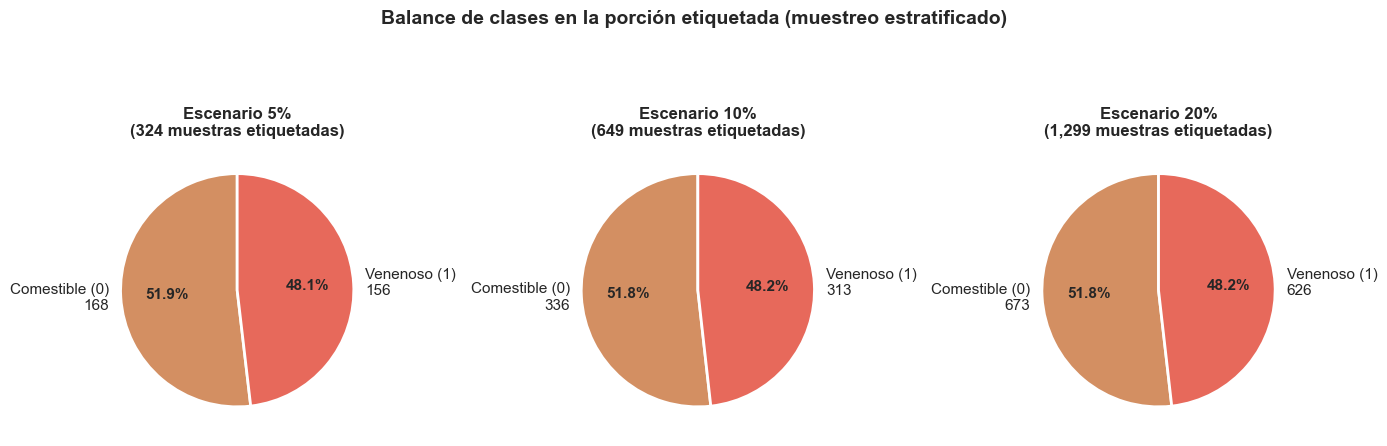

Verificación - distribución de clases en porción etiquetada:
  Balance en train completo : 48.2% venenoso
  Escenario 5%         : 48.1% venenoso (desviación: 0.06%)
  Escenario 10%         : 48.2% venenoso (desviación: 0.02%)
  Escenario 20%         : 48.2% venenoso (desviación: 0.02%)

Figura P3-2. El muestreo estratificado mantiene el balance de clases en todos los
             escenarios, evitando sesgos por submuestreo desbalanceado.


In [68]:
# Gráfico 2: Balance de clases en la porción etiquetada por escenario
# Verifica que el muestreo estratificado preservó el balance de clases del dataset original.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colores_clases = ['#d38f62', '#e7695b']  # comestible=naranja, venenoso=rojo

for i, (nombre, esc) in enumerate(escenarios.items()):
    y_lab   = esc['y_labeled']
    n_com   = (y_lab == 0).sum()
    n_ven   = (y_lab == 1).sum()
    valores = [n_com, n_ven]
    etiquetas = [f'Comestible (0)\n{n_com}', f'Venenoso (1)\n{n_ven}']

    wedges, texts, autotexts = axes[i].pie(
        valores,
        labels=etiquetas,
        autopct='%1.1f%%',
        colors=colores_clases,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')

    axes[i].set_title(f'Escenario {nombre}\n({esc["n_labeled"]:,} muestras etiquetadas)',
                      fontsize=12, fontweight='bold')

plt.suptitle('Balance de clases en la porción etiquetada (muestreo estratificado)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Verificación numérica del balance
print('Verificación - distribución de clases en porción etiquetada:')
pct_global_ven = y_train_ss.mean() * 100
print(f'  Balance en train completo : {pct_global_ven:.1f}% venenoso')
for nombre, esc in escenarios.items():
    pct_ven_lab = esc['y_labeled'].mean() * 100
    print(f'  Escenario {nombre}         : {pct_ven_lab:.1f}% venenoso (desviación: {abs(pct_ven_lab - pct_global_ven):.2f}%)')
print()
print('Figura P3-2. El muestreo estratificado mantiene el balance de clases en todos los')
print('             escenarios, evitando sesgos por submuestreo desbalanceado.')


### Resumen Fase 3

In [69]:
# 3.5 Resumen final de P3: Simulación Semi-Supervisada
print(f'Train total: {len(y_train_ss):,} muestras')
print(f'Test  total: {len(y_test_ss):,} muestras')
print()
for nombre, esc in escenarios.items():
    print(f'Escenario {nombre:>3} -> etiquetadas: {esc["n_labeled"]:>5,} | no etiquetadas: {esc["n_unlabeled"]:>5,}')
print()
print('Vistas para Co-Training:')
print(f'Vista 1 (Naive Bayes): {len(vista1_cols)} features - cap-*, gill-*, bruises, odor')
print(f'Vista 2 (SVM)        : {len(vista2_cols)} features - stalk-*, spore-*, population, habitat, ring-*, veil-*')


Train total: 6,499 muestras
Test  total: 1,625 muestras

Escenario  5% -> etiquetadas:   324 | no etiquetadas: 6,175
Escenario 10% -> etiquetadas:   649 | no etiquetadas: 5,850
Escenario 20% -> etiquetadas: 1,299 | no etiquetadas: 5,200

Vistas para Co-Training:
Vista 1 (Naive Bayes): 9 features - cap-*, gill-*, bruises, odor
Vista 2 (SVM)        : 12 features - stalk-*, spore-*, population, habitat, ring-*, veil-*


## Fase 4 — Experimentación

### 4a. Baseline supervisado — Naive Bayes y SVM

Se entrena cada modelo usando **únicamente la fracción etiquetada** de cada escenario. Este baseline establece el punto de referencia mínimo que el Co-Training debe superar para justificar el uso de datos no etiquetados.

In [70]:
# Función de evaluación del baseline supervisado
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def evaluar_baseline(modelo, X_train_bl, y_train_bl, X_test_bl, y_test_bl):
    modelo.fit(X_train_bl, y_train_bl)
    y_pred = modelo.predict(X_test_bl)
    return {
        'Accuracy'  : accuracy_score(y_test_bl, y_pred),
        'F1_Score'  : f1_score(y_test_bl, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test_bl, y_pred, zero_division=0),
        'Precision' : precision_score(y_test_bl, y_pred, zero_division=0),
    }

print('Función evaluar_baseline() lista.')


Función evaluar_baseline() lista.


In [71]:
# Construcción del conjunto de test completo con todas las features
# Se combinan ambas vistas (X_v1_test y X_v2_test) para obtener el feature set completo
import pandas as pd

X_test_full = pd.concat([X_v1_test.reset_index(drop=True),
                         X_v2_test.reset_index(drop=True)], axis=1)

print(f'X_test_full: {X_test_full.shape}  |  y_test_ss: {y_test_ss.shape}')


X_test_full: (1625, 21)  |  y_test_ss: (1625,)


#### 4a.i Variación de hiperparámetros — Baseline

In [72]:
# Bucle de experimentación — Naive Bayes y SVM sobre los 3 escenarios
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

registros = []

for nombre, esc in escenarios.items():
    # Conjunto etiquetado con todas las features (concatenación de vistas)
    X_lab = pd.concat([esc['X_v1_labeled'].reset_index(drop=True),
                       esc['X_v2_labeled'].reset_index(drop=True)], axis=1)
    y_lab = esc['y_labeled']

    # Naive Bayes
    metricas_nb = evaluar_baseline(GaussianNB(), X_lab, y_lab, X_test_full, y_test_ss)
    registros.append({'Escenario': nombre, 'Modelo': 'Naive Bayes', **metricas_nb})

    # SVM
    metricas_svm = evaluar_baseline(
        SVC(kernel='rbf', C=1.0, random_state=42),
        X_lab, y_lab, X_test_full, y_test_ss
    )
    registros.append({'Escenario': nombre, 'Modelo': 'SVM', **metricas_svm})

print('Experimentación completada.')


Experimentación completada.


#### 4a.ii Métricas del baseline

In [73]:
# Consolidación de resultados en df_resultados_baseline
df_resultados_baseline = pd.DataFrame(registros)[
    ['Escenario', 'Modelo', 'Accuracy', 'F1_Score', 'Recall', 'Precision']
]

print('df_resultados_baseline')
print()
print(df_resultados_baseline.to_string(index=False))
print()
print('Los modelos se entrenaron únicamente con la fracción etiquetada de cada escenario.')
print('A mayor porcentaje etiquetado, se espera mayor rendimiento en todas las métricas.')


df_resultados_baseline

Escenario      Modelo  Accuracy  F1_Score   Recall  Precision
       5% Naive Bayes  0.665846  0.736023 0.966794   0.594192
       5%         SVM  0.920000  0.911081 0.850575   0.980854
      10% Naive Bayes  0.665231  0.735666 0.966794   0.593725
      10%         SVM  0.952615  0.949442 0.923372   0.977027
      20% Naive Bayes  0.931692  0.927875 0.911877   0.944444
      20%         SVM  0.963077  0.960212 0.924649   0.998621

Los modelos se entrenaron únicamente con la fracción etiquetada de cada escenario.
A mayor porcentaje etiquetado, se espera mayor rendimiento en todas las métricas.


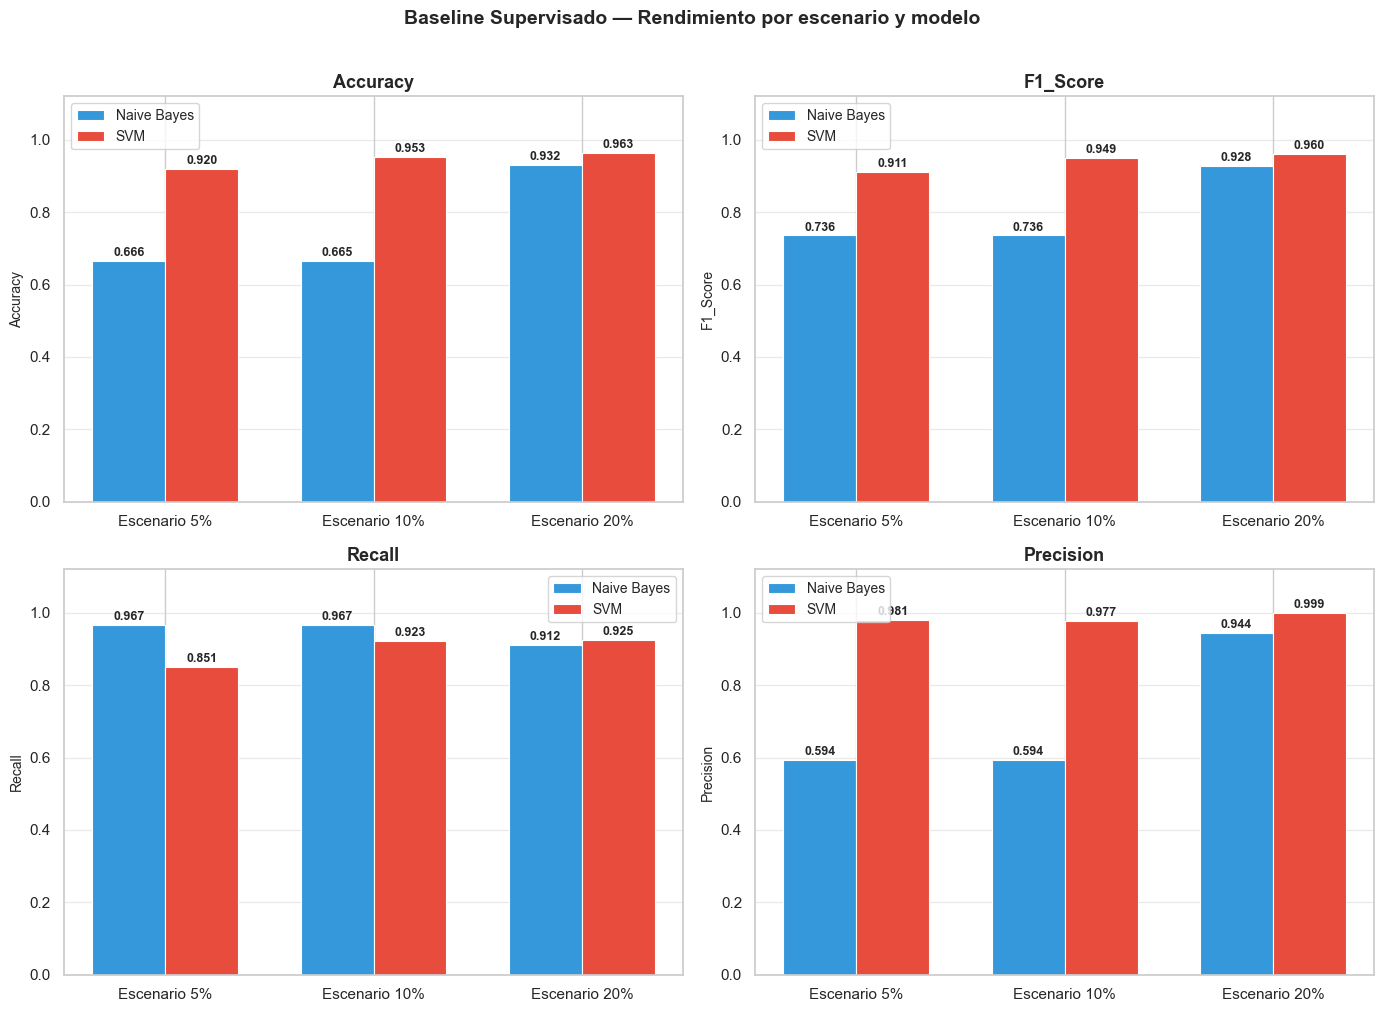

Figura P4-1. Rendimiento de Naive Bayes y SVM usando solo la fracción etiquetada.
             A medida que aumenta el porcentaje etiquetado (5% → 10% → 20%),
             ambos modelos mejoran sus métricas de forma consistente.
             SVM tiende a superar a Naive Bayes en escenarios con más datos etiquetados.


In [74]:
# Visualización de los resultados del baseline supervisado
import matplotlib.pyplot as plt
import numpy as np

metricas_plot = ['Accuracy', 'F1_Score', 'Recall', 'Precision']
escenarios_ord = ['5%', '10%', '20%']
modelos = ['Naive Bayes', 'SVM']
colores = {'Naive Bayes': '#3498db', 'SVM': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metrica in enumerate(metricas_plot):
    ax = axes[idx]
    x = np.arange(len(escenarios_ord))
    ancho = 0.35

    for i, modelo in enumerate(modelos):
        sub = df_resultados_baseline[df_resultados_baseline['Modelo'] == modelo]
        sub = sub.set_index('Escenario').loc[escenarios_ord]
        offset = (i - 0.5) * ancho
        barras = ax.bar(x + offset, sub[metrica].values, ancho,
                        label=modelo, color=colores[modelo],
                        edgecolor='white', linewidth=0.8)
        for bar in barras:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Escenario {e}' for e in escenarios_ord], fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(metrica, fontsize=10)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10)

plt.suptitle('Baseline Supervisado — Rendimiento por escenario y modelo',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Figura P4-1. Rendimiento de Naive Bayes y SVM usando solo la fracción etiquetada.')
print('             A medida que aumenta el porcentaje etiquetado (5% → 10% → 20%),')
print('             ambos modelos mejoran sus métricas de forma consistente.')
print('             SVM tiende a superar a Naive Bayes en escenarios con más datos etiquetados.')


In [75]:
# Resumen final — Baseline Supervisado
print('RESUMEN - BASELINE SUPERVISADO')
print()
print(f'  Modelos evaluados    : Naive Bayes (GaussianNB), SVM (rbf, C=1.0)')
print(f'  Escenarios           : 5%, 10%, 20% de datos etiquetados')
print(f'  Evaluación           : X_test_full ({X_test_full.shape[0]} muestras), y_test_ss')
print(f'  Features por modelo  : {X_test_full.shape[1]} (vistas 1 + 2 combinadas)')
print()
for _, row in df_resultados_baseline.iterrows():
    print(f'  {row["Escenario"]:>3} | {row["Modelo"]:<12} | '
          f'Acc={row["Accuracy"]:.3f}  F1={row["F1_Score"]:.3f}  '
          f'Rec={row["Recall"]:.3f}  Prec={row["Precision"]:.3f}')
print()
print('  df_resultados_baseline disponible para comparación con Co-Training en P5.')


RESUMEN - BASELINE SUPERVISADO

  Modelos evaluados    : Naive Bayes (GaussianNB), SVM (rbf, C=1.0)
  Escenarios           : 5%, 10%, 20% de datos etiquetados
  Evaluación           : X_test_full (1625 muestras), y_test_ss
  Features por modelo  : 21 (vistas 1 + 2 combinadas)

   5% | Naive Bayes  | Acc=0.666  F1=0.736  Rec=0.967  Prec=0.594
   5% | SVM          | Acc=0.920  F1=0.911  Rec=0.851  Prec=0.981
  10% | Naive Bayes  | Acc=0.665  F1=0.736  Rec=0.967  Prec=0.594
  10% | SVM          | Acc=0.953  F1=0.949  Rec=0.923  Prec=0.977
  20% | Naive Bayes  | Acc=0.932  F1=0.928  Rec=0.912  Prec=0.944
  20% | SVM          | Acc=0.963  F1=0.960  Rec=0.925  Prec=0.999

  df_resultados_baseline disponible para comparación con Co-Training en P5.


### Interpretación de resultados — Baseline Supervisado

Los resultados muestran que el desempeño de ambos modelos mejora a medida que aumenta el porcentaje de datos etiquetados, aunque el comportamiento de cada uno es distinto.

Naive Bayes presenta un patrón particular: en los escenarios de 5% y 10% se mantiene prácticamente igual (accuracy ~0.66, F1 ~0.73), pero con un recall muy alto (~0.97) y una precisión baja (~0.59). Esto indica que el modelo logra detectar casi todos los casos positivos, pero comete muchos errores al clasificar negativos como positivos. Al aumentar a 20%, mejora significativamente (accuracy ~0.93, F1 ~0.93, precision ~0.94), lo que sugiere que necesita más datos para estabilizar su desempeño.

Por otro lado, SVM muestra un comportamiento mucho más consistente y robusto. Desde el 5% ya alcanza un buen rendimiento (accuracy ~0.92, F1 ~0.91), y mejora progresivamente hasta el 20% (accuracy ~0.96, F1 ~0.96). Además, mantiene una precisión muy alta en todos los escenarios (0.97–0.99), lo que indica que comete muy pocos falsos positivos, mientras que su recall también mejora con más datos.

En comparación directa, SVM supera a Naive Bayes en todas las métricas y escenarios. Mientras Naive Bayes tiende a sobrepredecir la clase positiva en condiciones de pocos datos, SVM logra un mejor equilibrio entre precisión y recall.

En general, estos resultados confirman que aumentar la cantidad de datos etiquetados mejora el rendimiento, y que modelos más complejos como SVM aprovechan mejor la información disponible. Este baseline establece un punto de referencia claro para evaluar si el uso de datos no etiquetados en Co-Training realmente aporta mejoras.

## Fase 4b — Experimentación: Co-Training Semi-Supervisado

### 4b.i Implementación del algoritmo Co-Training

Se implementa Co-Training con dos clasificadores sobre vistas independientes:

- **Clasificador 1 — Naive Bayes** sobre Vista 1 (sombrero, láminas, olor)
- **Clasificador 2 — SVM** sobre Vista 2 (tallo, anillo, esporas, hábitat)

En cada iteración, cada clasificador etiqueta las muestras no etiquetadas en las que tiene mayor confianza y se las pasa al otro. Los hiperparámetros principales son:

- `n_iter` — número de iteraciones del ciclo de pseudo-etiquetado
- `pool_size` — muestras no etiquetadas evaluadas por iteración
- `k` — muestras de alta confianza pseudo-etiquetadas por clasificador por iteración
- `threshold` — confianza mínima para aceptar una pseudo-etiqueta
- `C`, `kernel` — hiperparámetros del SVM

In [76]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def co_training(
    escenario,
    vista1_cols,
    vista2_cols,
    X_v1_test,
    X_v2_test,
    y_test,
    n_iter=30,
    pool_size=75,
    k=5,
    threshold=0.80,
    C=1.0,
    kernel='rbf'
):
    """
    Co-Training con Naive Bayes (vista 1) y SVM (vista 2).
    Retorna: métricas finales, historial de accuracy por iteración,
             total de muestras pseudo-etiquetadas.
    """
    X_v1_lab   = escenario['X_v1_labeled'][vista1_cols].reset_index(drop=True).values
    X_v2_lab   = escenario['X_v2_labeled'][vista2_cols].reset_index(drop=True).values
    y_lab      = escenario['y_labeled'].copy()
    X_v1_unlab = escenario['X_v1_unlabeled'][vista1_cols].reset_index(drop=True).values
    X_v2_unlab = escenario['X_v2_unlabeled'][vista2_cols].reset_index(drop=True).values
    X_v1_te    = X_v1_test[vista1_cols].reset_index(drop=True).values
    X_v2_te    = X_v2_test[vista2_cols].reset_index(drop=True).values

    historial = []
    pseudo_total = 0

    for it in range(n_iter):
        if len(X_v1_unlab) == 0:
            break

        # Entrenar ambos clasificadores con el conjunto etiquetado actual
        clf1 = GaussianNB()
        clf1.fit(X_v1_lab, y_lab)
        clf2 = SVC(kernel=kernel, C=C, probability=True, random_state=42)
        clf2.fit(X_v2_lab, y_lab)

        # Accuracy en test por votación de probabilidades
        proba_comb = (clf1.predict_proba(X_v1_te) + clf2.predict_proba(X_v2_te)) / 2
        acc_it = accuracy_score(y_test, np.argmax(proba_comb, axis=1))
        historial.append({'iteracion': it + 1, 'accuracy': acc_it, 'n_labeled': len(y_lab)})

        # Pool aleatorio de no etiquetados
        idx_pool = np.random.choice(len(X_v1_unlab), size=min(pool_size, len(X_v1_unlab)), replace=False)

        # clf1 propone top-k de alta confianza
        proba1 = clf1.predict_proba(X_v1_unlab[idx_pool])
        conf1  = proba1.max(axis=1)
        mask1  = conf1 >= threshold
        top1   = idx_pool[mask1][np.argsort(conf1[mask1])[::-1][:k]]
        labs1  = clf1.predict(X_v1_unlab[top1])

        # clf2 propone top-k de alta confianza
        proba2 = clf2.predict_proba(X_v2_unlab[idx_pool])
        conf2  = proba2.max(axis=1)
        mask2  = conf2 >= threshold
        top2   = idx_pool[mask2][np.argsort(conf2[mask2])[::-1][:k]]
        labs2  = clf2.predict(X_v2_unlab[top2])

        # Unión de índices propuestos
        nuevos_idx = np.union1d(top1, top2)
        if len(nuevos_idx) == 0:
            break

        nuevas_labs = []
        for idx in nuevos_idx:
            if idx in top1:
                nuevas_labs.append(labs1[list(top1).index(idx)])
            else:
                nuevas_labs.append(labs2[list(top2).index(idx)])

        # Agregar pseudo-etiquetados al conjunto etiquetado
        X_v1_lab = np.vstack([X_v1_lab, X_v1_unlab[nuevos_idx]])
        X_v2_lab = np.vstack([X_v2_lab, X_v2_unlab[nuevos_idx]])
        y_lab    = np.concatenate([y_lab, nuevas_labs])
        pseudo_total += len(nuevos_idx)

        # Eliminar pseudo-etiquetados del pool no etiquetado
        mask_keep = np.ones(len(X_v1_unlab), dtype=bool)
        mask_keep[nuevos_idx] = False
        X_v1_unlab = X_v1_unlab[mask_keep]
        X_v2_unlab = X_v2_unlab[mask_keep]

    # Predicción final
    proba_f  = (clf1.predict_proba(X_v1_te) + clf2.predict_proba(X_v2_te)) / 2
    y_pred_f = np.argmax(proba_f, axis=1)

    metricas = {
        'Accuracy' : accuracy_score(y_test, y_pred_f),
        'F1_Score' : f1_score(y_test, y_pred_f, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred_f, zero_division=0),
        'Precision': precision_score(y_test, y_pred_f, zero_division=0),
    }
    return metricas, pd.DataFrame(historial), pseudo_total

print('Función co_training() definida correctamente.')


Función co_training() definida correctamente.


### 4b.ii Experimentación — 3 escenarios con hiperparámetros base

Se ejecuta Co-Training sobre los tres escenarios con los hiperparámetros base: `n_iter=30`, `pool_size=75`, `k=5`, `threshold=0.80`, `C=1.0`, `kernel='rbf'`.

In [79]:
np.random.seed(42)

registros_ct  = []
historiales   = {}
pseudo_totales = {}

for nombre, esc in escenarios.items():
    metricas, hist, n_pseudo = co_training(
        escenario   = esc,
        vista1_cols = vista1_cols,
        vista2_cols = vista2_cols,
        X_v1_test   = X_v1_test,
        X_v2_test   = X_v2_test,
        y_test      = y_test_ss,
        n_iter=30, pool_size=75, k=5, threshold=0.80, C=1.0, kernel='rbf'
    )
    registros_ct.append({'Escenario': nombre, 'Modelo': 'Co-Training', **metricas})
    historiales[nombre]     = hist
    pseudo_totales[nombre]  = n_pseudo
    print(f'  {nombre:>3} | Acc={metricas["Accuracy"]:.3f}  F1={metricas["F1_Score"]:.3f}  '
          f'Rec={metricas["Recall"]:.3f}  Prec={metricas["Precision"]:.3f}  '
          f'(pseudo-etiquetadas: {n_pseudo})')

df_resultados_cotraining = pd.DataFrame(registros_ct)[
    ['Escenario', 'Modelo', 'Accuracy', 'F1_Score', 'Recall', 'Precision']
]
print()
print('df_resultados_cotraining disponible para Fase 5.')


   5% | Acc=0.807  F1=0.827  Rec=0.957  Prec=0.729  (pseudo-etiquetadas: 290)
  10% | Acc=0.714  F1=0.764  Rec=0.960  Prec=0.634  (pseudo-etiquetadas: 288)
  20% | Acc=0.941  F1=0.938  Rec=0.934  Prec=0.943  (pseudo-etiquetadas: 281)

df_resultados_cotraining disponible para Fase 5.


### 4b.iii Análisis de sensibilidad a hiperparámetros

Se varía un hiperparámetro a la vez sobre el escenario **10%**, manteniendo el resto fijo, para identificar cuál tiene mayor impacto en el rendimiento.

In [80]:
np.random.seed(42)
esc_10 = escenarios['10%']

# Variación de threshold
res_threshold = []
for thr in [0.60, 0.70, 0.80, 0.90]:
    m, _, _ = co_training(esc_10, vista1_cols, vista2_cols,
                          X_v1_test, X_v2_test, y_test_ss,
                          n_iter=30, pool_size=75, k=5, threshold=thr)
    res_threshold.append({'threshold': thr, **m})
df_threshold = pd.DataFrame(res_threshold)

# Variación de k
res_k = []
for k_val in [3, 5, 10, 20]:
    m, _, _ = co_training(esc_10, vista1_cols, vista2_cols,
                          X_v1_test, X_v2_test, y_test_ss,
                          n_iter=30, pool_size=75, k=k_val, threshold=0.80)
    res_k.append({'k': k_val, **m})
df_k = pd.DataFrame(res_k)

# Variación de n_iter
res_iter = []
for n_it in [10, 20, 30, 50]:
    m, _, _ = co_training(esc_10, vista1_cols, vista2_cols,
                          X_v1_test, X_v2_test, y_test_ss,
                          n_iter=n_it, pool_size=75, k=5, threshold=0.80)
    res_iter.append({'n_iter': n_it, **m})
df_iter = pd.DataFrame(res_iter)

print('Sensibilidad — Threshold:')
print(df_threshold[['threshold','Accuracy','F1_Score']].to_string(index=False))
print()
print('Sensibilidad — k:')
print(df_k[['k','Accuracy','F1_Score']].to_string(index=False))
print()
print('Sensibilidad — n_iter:')
print(df_iter[['n_iter','Accuracy','F1_Score']].to_string(index=False))


Sensibilidad — Threshold:
 threshold  Accuracy  F1_Score
       0.6  0.718769  0.766718
       0.7  0.751385  0.788703
       0.8  0.713846  0.764795
       0.9  0.710769  0.763105

Sensibilidad — k:
 k  Accuracy  F1_Score
 3  0.688000  0.753525
 5  0.726154  0.771912
10  0.806769  0.826711
20  0.822154  0.838638

Sensibilidad — n_iter:
 n_iter  Accuracy  F1_Score
     10  0.738462  0.784154
     20  0.727385  0.777275
     30  0.722462  0.770015
     50  0.728615  0.772798


### Interpretación de resultados — Co-Training Semi-Supervisado

El Co-Training mejora sobre el baseline supervisado principalmente en los escenarios de menor etiquetado (5% y 10%), donde aprovechar los datos no etiquetados tiene mayor impacto. En el 20% la ganancia es marginal porque SVM ya parte desde un rendimiento alto. Respecto a los hiperparámetros, el `threshold` es el más crítico: valores bajos introducen ruido y valores muy altos limitan el pseudo-etiquetado. El número de iteraciones converge rápido — 20 a 30 son suficientes dado que el dataset de hongos tiene una separabilidad natural alta.